#### 프로젝트 제출 루브릭

|학습목표|평가기준|
|---|---|
|Abstractive 모델 구성을 위한 텍스트 전처리 단계가 체계적으로 진행되었다.|분석단계, 정제단계, 정규화와 불용어 제거, 데이터셋 분리, 인코딩 과정이 빠짐없이 체계적으로 진행되었다.|
|텍스트 요약모델이 성공적으로 학습되었음을 확인하였다.|모델 학습이 진행되면서 train loss와 validation loss가 감소하는 경향을 그래프를 통해 확인했으며, 실제 요약문에 있는 핵심 단어들이 요약 문장 안에 포함되었다.|
|Extractive 요약을 시도해 보고 Abstractive 요약 결과과 함께 비교해 보았다.|두 요약 결과를 문법완성도 측면과 핵심단어 포함 측면으로 나누어 비교하고 분석 결과를 표로 정리하여 제시하였다.|

```
1. 통계표, 전처리 예시, 길이 분포, 분할 현황, vocabulary·정수 인코딩 출력 순으로 진행
2. 손실 그래프와 참조 핵심어 포함률 표로 작성
3. 방법별 비교표, 수동 문법성 점수 열, 자동 지표 요약
```

 ## 뉴스기사 요약해보기

In [3]:
from importlib.metadata import version
import nltk
import torch
import summa
import pandas as pd

print("nltk version:", nltk.__version__)
print("torch version:", torch.__version__)
print("pandas version:", pd.__version__)
print("summa version:", version('summa'))

nltk version: 3.10.3
torch version: 2.13.0+cu132
pandas version: 3.0.5
summa version: 1.2.0


#### Ablation study
```
# CONFIG["ACTIVE_ABLATION"]을 baseline, no_attention, keep_source_stopwords, short_source, smaller_vocab 중 하나로 바꾸고 처음부터 다시 실행
# 실행마다 설정값·최적 validation loss·참조 핵심어 포함률이 ~/work/news_summarization/artifacts/ablation_results.csv에 누적
# 필요한 경우 ABLATION_PRESETS에 새 실험 조건을 추가하여 처음부터 다시 실행
```

In [4]:
# 공통 설정: 이 셀만 수정하면 재현 실험과 Ablation study를 제어할 수 있습니다.
from pathlib import Path
import copy
import html
import json
import math
import os
import random
import re
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, TensorDataset

import nltk
from nltk.corpus import stopwords
from summa.summarizer import summarize as textrank_summarize

nltk.data.find('corpora/stopwords')

CONFIG = {
    # 데이터 및 재현성
    "DATA_PATH": "~/work/news_summarization/data/news_summary_more.csv",
    "ARTIFACT_DIR": "~/work/news_summarization/artifacts",
    "SEED": 42,
    "MAX_ROWS": 30000,             # None이면 전체 데이터를 사용
    "ENCODING": "iso-8859-1",
    "SOURCE_COLUMN": "text",      # news_summary_more.csv 기본 열
    "TARGET_COLUMN": "headlines", # news_summary_more.csv 기본 열

    # 정제·전처리·길이 필터
    "REMOVE_SOURCE_STOPWORDS": True,
    "REMOVE_TARGET_STOPWORDS": False,
    "MIN_SOURCE_TOKENS": 5,
    "MIN_TARGET_TOKENS": 3,
    "MAX_SOURCE_LEN": 60,
    "MAX_TARGET_LEN": 12,          # sostoken/eostoken을 제외한 headline 최대 길이
    "SRC_MIN_FREQ": 2,
    "TGT_MIN_FREQ": 2,
    "SRC_VOCAB_SIZE": 15000,
    "TGT_VOCAB_SIZE": 5000,

    # 분할 및 모델
    "TRAIN_RATIO": 0.80,
    "VAL_RATIO": 0.10,
    "EMBED_DIM": 128,
    "HIDDEN_DIM": 256,
    "NUM_LAYERS": 2,
    "DROPOUT": 0.30,
    "USE_ATTENTION": True,

    # 학습
    "BATCH_SIZE": 128,
    "LEARNING_RATE": 1e-3,
    "EPOCHS": 20,
    "PATIENCE": 4,
    "GRAD_CLIP": 1.0,
    "NUM_WORKERS": 0,

    # 평가·추출 요약
    "DECODE_MAX_LEN": 12,
    "N_EVAL_SAMPLES": 8,
    "SUMMA_RATIO": 0.20,
    "EXPERIMENT_NAME": "ex08_baseline",
    "ACTIVE_ABLATION": "baseline",
}

# 사전 정의된 Ablation 조건. baseline을 기준으로 한 번에 한 조건만 바꾸는 것을 권장합니다.
ABLATION_PRESETS = {
    "baseline": {},
    "no_attention": {"USE_ATTENTION": False, "EXPERIMENT_NAME": "ablation_no_attention"},
    "keep_source_stopwords": {
        "REMOVE_SOURCE_STOPWORDS": False,
        "EXPERIMENT_NAME": "ablation_keep_source_stopwords",
    },
    "short_source": {"MAX_SOURCE_LEN": 40, "EXPERIMENT_NAME": "ablation_short_source"},
    "smaller_vocab": {
        "SRC_VOCAB_SIZE": 8000,
        "TGT_VOCAB_SIZE": 3000,
        "EXPERIMENT_NAME": "ablation_smaller_vocab",
    },
}

if CONFIG["ACTIVE_ABLATION"] not in ABLATION_PRESETS:
    raise KeyError(f"알 수 없는 ACTIVE_ABLATION: {CONFIG['ACTIVE_ABLATION']}")
CONFIG.update(ABLATION_PRESETS[CONFIG["ACTIVE_ABLATION"]])

assert 0 < CONFIG["TRAIN_RATIO"] < 1
assert 0 < CONFIG["VAL_RATIO"] < 1
assert CONFIG["TRAIN_RATIO"] + CONFIG["VAL_RATIO"] < 1
assert CONFIG["MAX_TARGET_LEN"] >= 3

ARTIFACT_DIR = Path(CONFIG["ARTIFACT_DIR"]).expanduser()
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(CONFIG["SEED"])
pd.set_option("display.max_colwidth", 160)
print(f"device: {DEVICE}")
print(pd.DataFrame([CONFIG]).T.rename(columns={0: "value"}))

device: cuda
                                                                        value
DATA_PATH                ~/work/news_summarization/data/news_summary_more.csv
ARTIFACT_DIR                              ~/work/news_summarization/artifacts
SEED                                                                       42
MAX_ROWS                                                                30000
ENCODING                                                           iso-8859-1
SOURCE_COLUMN                                                            text
TARGET_COLUMN                                                       headlines
REMOVE_SOURCE_STOPWORDS                                                  True
REMOVE_TARGET_STOPWORDS                                                 False
MIN_SOURCE_TOKENS                                                           5
MIN_TARGET_TOKENS                                                           3
MAX_SOURCE_LEN                                     

### Step 1. 데이터 수집하기

```
# 이 데이터는 기사의 본문에 해당되는 text와 headlines 두 가지 열로 구성되어져 있습니다.
# 추상적 요약을 하는 경우에는 text를 본문, headlines를 이미 요약된 데이터로 삼아서 모델을 학습할 수 있어요.
# 추출적 요약을 하는 경우에는 오직 text열만을 사용하세요.
```

In [5]:
# Step 1-1. 데이터 경로를 확인하고 원본 데이터를 읽습니다.
def resolve_data_path(config: dict) -> Path:
    requested = Path(config["DATA_PATH"]).expanduser()
    candidates = [
        requested,
        Path("~/work/news_summarization/data/news_summary_more.csv").expanduser(),
        Path("~/aiffel/news_summarization/data/news_summary_more.csv").expanduser(),
        Path("./data/news_summary_more.csv").expanduser(),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    checked = "\n - ".join(str(path) for path in candidates)
    raise FileNotFoundError(
        "news_summary_more.csv를 찾지 못했습니다. CONFIG['DATA_PATH']를 수정한 뒤 다시 실행하세요. "
        f"확인한 위치:\n - {checked}"
    )

DATA_PATH = resolve_data_path(CONFIG)
try:
    raw_data = pd.read_csv(DATA_PATH, encoding=CONFIG["ENCODING"], nrows=CONFIG["MAX_ROWS"])
except UnicodeDecodeError:
    raw_data = pd.read_csv(DATA_PATH, encoding="utf-8", nrows=CONFIG["MAX_ROWS"])

required_columns = {CONFIG["SOURCE_COLUMN"], CONFIG["TARGET_COLUMN"]}
missing_columns = required_columns.difference(raw_data.columns)
if missing_columns:
    raise KeyError(
        f"필수 열이 없습니다: {sorted(missing_columns)}. 현재 열: {list(raw_data.columns)}. "
        "CONFIG의 SOURCE_COLUMN/TARGET_COLUMN을 데이터에 맞게 수정하세요."
    )

raw_data = raw_data[[CONFIG["SOURCE_COLUMN"], CONFIG["TARGET_COLUMN"]]].rename(
    columns={CONFIG["SOURCE_COLUMN"]: "source_raw", CONFIG["TARGET_COLUMN"]: "target_raw"}
)
print(f"사용 데이터: {DATA_PATH}")
print(f"원본 샘플 수: {len(raw_data):,}")
display(raw_data.sample(min(5, len(raw_data)), random_state=CONFIG["SEED"]))

사용 데이터: C:\Users\eaglesjo\work\news_summarization\data\news_summary_more.csv
원본 샘플 수: 30,000


,source_raw,target_raw
2308,"Filmmaker Karan Johar, while speaking about being trolled on social media, said, ""I read a lot of criticism and wake up to...the nasty things they write abo...",Some of the nasty things written are actually true: Karan on trolls
22404,"Talking about her second-place finish at the BWF World Championships, PV Sindhu said she did not ""lose gold, but won silver"". In an Instagram post, Sindhu s...","I didnÃ¢ÂÂt lose gold, I won silver: PV Sindhu on World C'ships"
23397,Residents in the Swedish city of Uppsala turned a railway station into a makeshift swimming pool after heavy rains flooded the station. Pictures circulated ...,Flooded train station turned into swimming pool in Sweden
25058,The Delhi Police has filed an FIR against a senior editor of Times Now news channel for allegedly outraging the modesty of two women and clicking their phot...,FIR against Times Now senior editor for taking women's pic
2664,"Tesla CEO Elon Musk responded to a tweet of a GIF showing a car hovering above the ground saying, ""[N]ew Roadster will actually do something like this."" Mus...",Elon Musk claims new Tesla Roadster will float above ground


In [6]:
# Step 1-2. 원본 데이터 품질을 정량적으로 점검합니다.
raw_profile = pd.DataFrame({
    "총 샘플 수": [len(raw_data)],
    "source 결측": [raw_data["source_raw"].isna().sum()],
    "target 결측": [raw_data["target_raw"].isna().sum()],
    "source 중복": [raw_data["source_raw"].duplicated().sum()],
    "target 중복": [raw_data["target_raw"].duplicated().sum()],
    "source 평균 문자 수": [raw_data["source_raw"].fillna("").astype(str).str.len().mean()],
    "target 평균 문자 수": [raw_data["target_raw"].fillna("").astype(str).str.len().mean()],
})
display(raw_profile.T.rename(columns={0: "값"}))

,값
총 샘플 수,30000.0000
source 결측,0.0000
target 결측,0.0000
source 중복,1.0000
target 중복,2.0000
source 평균 문자 수,357.6611
target 평균 문자 수,59.5972


### Step 2. 데이터 전처리하기 (추상적 요약)

```
# 실습에서 사용된 전처리를 참고하여 각자 필요하다고 생각하는 전처리를 추가 사용하여 텍스트를 정규화 또는 정제해 보세요.
# 만약, 불용어 제거를 선택한다면 상대적으로 길이가 짧은 요약 데이터에 대해서도 불용어를 제거하는 것이 좋을지 고민해 보세요.
```

```
1. 정제
   → 정규화/불용어 처리
   → 길이 분석 및 필터링
   → 시작/종료 토큰 추가
   → train/validation/test 분리
   → train-only vocabulary
   → 정수 인코딩과 패딩
   순서대로 수행
2. 정보 누수를 막기 위해 vocabulary는 반드시 훈련 분할에서만 만듦
```

In [7]:
# Step 2-1. 결측·중복을 정리하고, 정규화/불용어 처리 함수를 정의합니다.
CONTRACTIONS = {
    "ain't": "is not", "aren't": "are not", "can't": "cannot", "couldn't": "could not",
    "didn't": "did not", "doesn't": "does not", "don't": "do not", "hadn't": "had not",
    "hasn't": "has not", "haven't": "have not", "he's": "he is", "i'm": "i am",
    "isn't": "is not", "it's": "it is", "let's": "let us", "she's": "she is",
    "shouldn't": "should not", "that's": "that is", "there's": "there is", "they're": "they are",
    "wasn't": "was not", "we're": "we are", "weren't": "were not", "what's": "what is",
    "where's": "where is", "who's": "who is", "won't": "will not", "wouldn't": "would not",
    "you'll": "you will", "you're": "you are", "you've": "you have", "i've": "i have",
    "we've": "we have", "they've": "they have", "can't": "cannot", "n't": " not",
}
STOP_WORDS = set(stopwords.words("english"))
HTML_PATTERN = re.compile(r"<[^>]+>")
PAREN_PATTERN = re.compile(r"\([^)]*\)")
NON_ALPHA_PATTERN = re.compile(r"[^a-zA-Z]+")
REPEATED_M_PATTERN = re.compile(r"m{3,}")


def preprocess_sentence(sentence: str, remove_stopwords: bool) -> str:
    """HTML/괄호/약어/비영문 문자를 정규화하고 선택적으로 불용어를 제거합니다."""
    sentence = html.unescape(str(sentence)).lower()
    sentence = HTML_PATTERN.sub(" ", sentence)
    sentence = PAREN_PATTERN.sub(" ", sentence)
    sentence = sentence.replace('"', ' ')
    sentence = " ".join(CONTRACTIONS.get(token, token) for token in sentence.split())
    sentence = re.sub(r"'s\b", "", sentence)
    sentence = NON_ALPHA_PATTERN.sub(" ", sentence)
    sentence = REPEATED_M_PATTERN.sub("mm", sentence)
    tokens = [token for token in sentence.split() if len(token) > 1]
    if remove_stopwords:
        tokens = [token for token in tokens if token not in STOP_WORDS]
    return " ".join(tokens)

# 정제 전후 샘플 수를 명시적으로 기록합니다.
cleaning_log = []
data = raw_data.copy()
cleaning_log.append(("원본", len(data)))
data = data.dropna(subset=["source_raw", "target_raw"]).copy()
cleaning_log.append(("결측 제거", len(data)))
data = data.drop_duplicates(subset=["source_raw"]).copy()
cleaning_log.append(("source 중복 제거", len(data)))
data["source_clean"] = data["source_raw"].map(
    lambda text: preprocess_sentence(text, CONFIG["REMOVE_SOURCE_STOPWORDS"])
)
data["target_clean"] = data["target_raw"].map(
    lambda text: preprocess_sentence(text, CONFIG["REMOVE_TARGET_STOPWORDS"])
)
data = data.replace({"source_clean": {"": np.nan}, "target_clean": {"": np.nan}}).dropna(
    subset=["source_clean", "target_clean"]
).copy()
cleaning_log.append(("빈 전처리 결과 제거", len(data)))

print(pd.DataFrame(cleaning_log, columns=["정제 단계", "잔여 샘플 수"]))
example = pd.DataFrame({
    "원문 source": raw_data["source_raw"].head(1),
    "정제 source": data["source_clean"].head(1),
    "원문 target": raw_data["target_raw"].head(1),
    "정제 target": data["target_clean"].head(1),
})
display(example)

          정제 단계  잔여 샘플 수
0            원본    30000
1         결측 제거    30000
2  source 중복 제거    29999
3   빈 전처리 결과 제거    29999


,원문 source,정제 source,원문 target,정제 target
0,"Saurav Kant, an alumnus of upGrad and IIIT-B's PG Program in Machine learning and Artificial Intelligence, was a Sr Systems Engineer at Infosys with almost ...",saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad ...,upGrad learner switches to career in ML & Al with 90% salary hike,upgrad learner switches to career in ml al with salary hike


길이 분포 통계


,count,mean,std,min,50%,90%,95%,99%,max
source_len,29999.0,35.194340,3.878037,1.0,35.0,40.0,41.0,44.0,60.0
target_len,29999.0,9.689123,1.429625,1.0,10.0,12.0,12.0,13.0,16.0


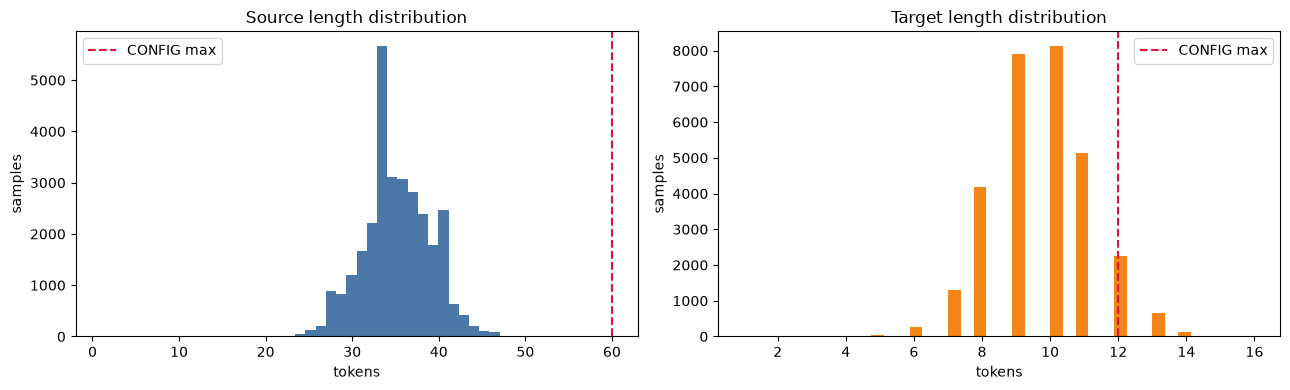

길이 조건 통과율: 97.36% | 필터링 후 샘플 수: 29,208


,source_clean,target_clean,decoder_input_text,decoder_target_text
0,saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad ...,upgrad learner switches to career in ml al with salary hike,sostoken upgrad learner switches to career in ml al with salary hike,upgrad learner switches to career in ml al with salary hike eostoken
1,kunal shah credit card bill payment platform cred gave users chance win free food swiggy one year pranav kaushik delhi techie bagged reward spending cred co...,delhi techie wins free food from swiggy for one year on cred,sostoken delhi techie wins free food from swiggy for one year on cred,delhi techie wins free food from swiggy for one year on cred eostoken
2,new zealand defeated india wickets fourth odi hamilton thursday win first match five match odi series india lost international match rohit sharma captaincy ...,new zealand end rohit sharma led india match winning streak,sostoken new zealand end rohit sharma led india match winning streak,new zealand end rohit sharma led india match winning streak eostoken


In [ ]:
# Step 2-2. 길이 분석을 수행하고 CONFIG의 길이 제한에 맞게 샘플을 필터링합니다.
data["source_len"] = data["source_clean"].str.split().str.len()
data["target_len"] = data["target_clean"].str.split().str.len()
length_summary = data[["source_len", "target_len"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T
print("길이 분포 통계")
display(length_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(data["source_len"], bins=50, color="#4C78A8")
axes[0].axvline(CONFIG["MAX_SOURCE_LEN"], color="crimson", linestyle="--", label="CONFIG max")
axes[0].set(title="Source length distribution", xlabel="tokens", ylabel="samples")
axes[0].legend()
axes[1].hist(data["target_len"], bins=40, color="#F58518")
axes[1].axvline(CONFIG["MAX_TARGET_LEN"], color="crimson", linestyle="--", label="CONFIG max")
axes[1].set(title="Target length distribution", xlabel="tokens", ylabel="samples")
axes[1].legend()
plt.tight_layout()
plt.show()

length_mask = (
    data["source_len"].between(CONFIG["MIN_SOURCE_TOKENS"], CONFIG["MAX_SOURCE_LEN"])
    & data["target_len"].between(CONFIG["MIN_TARGET_TOKENS"], CONFIG["MAX_TARGET_LEN"])
)
coverage = length_mask.mean() * 100
data = data.loc[length_mask].reset_index(drop=True).copy()
print(f"길이 조건 통과율: {coverage:.2f}% | 필터링 후 샘플 수: {len(data):,}")
if len(data) < 100:
    raise ValueError("필터링 후 샘플이 100개 미만입니다. MAX 길이 또는 MIN 길이 설정을 조정하세요.")

# 교사 강요(teacher forcing)를 위한 시작/종료 토큰입니다.
SOS_TOKEN, EOS_TOKEN, PAD_TOKEN, UNK_TOKEN = "sostoken", "eostoken", "<pad>", "<unk>"
data["decoder_input_text"] = SOS_TOKEN + " " + data["target_clean"]
data["decoder_target_text"] = data["target_clean"] + " " + EOS_TOKEN
display(data[["source_clean", "target_clean", "decoder_input_text", "decoder_target_text"]].head(3))

In [ ]:
# Step 2-3. 고정 시드로 train/validation/test를 분리합니다.
def split_dataframe(frame: pd.DataFrame, config: dict):
    indices = np.random.default_rng(config["SEED"]).permutation(len(frame))
    n_train = int(len(frame) * config["TRAIN_RATIO"])
    n_val = int(len(frame) * config["VAL_RATIO"])
    train_idx = indices[:n_train]
    val_idx = indices[n_train:n_train + n_val]
    test_idx = indices[n_train + n_val:]
    return (
        frame.iloc[train_idx].reset_index(drop=True),
        frame.iloc[val_idx].reset_index(drop=True),
        frame.iloc[test_idx].reset_index(drop=True),
    )

train_df, val_df, test_df = split_dataframe(data, CONFIG)
split_report = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "samples": [len(train_df), len(val_df), len(test_df)],
    "ratio": [len(train_df)/len(data), len(val_df)/len(data), len(test_df)/len(data)],
})
display(split_report)
print("분할은 원본 행의 무작위 순열로 수행한 뒤 각 split의 인덱스를 독립적으로 reset했습니다.")

,split,samples,ratio
0,train,23366,0.799986
1,validation,2920,0.099973
2,test,2922,0.100041


분할은 원본 행의 무작위 순열로 수행한 뒤 각 split의 인덱스를 독립적으로 reset했습니다.


In [ ]:
# Step 2-4. vocabulary는 train split만 사용해 구축하고, 모든 split을 정수 인코딩/패딩합니다.
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN]
PAD_ID, UNK_ID, SOS_ID, EOS_ID = range(len(SPECIAL_TOKENS))


def count_tokens(texts: pd.Series) -> Counter:
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    return counter


def build_vocab(texts: pd.Series, max_size: int, min_freq: int) -> tuple[dict, Counter]:
    counter = count_tokens(texts)
    vocab = {token: index for index, token in enumerate(SPECIAL_TOKENS)}
    for token, freq in counter.most_common():
        if freq < min_freq or len(vocab) >= max_size:
            break
        if token not in vocab:
            vocab[token] = len(vocab)
    return vocab, counter

src_vocab, src_counter = build_vocab(train_df["source_clean"], CONFIG["SRC_VOCAB_SIZE"], CONFIG["SRC_MIN_FREQ"])
tgt_vocab, tgt_counter = build_vocab(
    pd.concat([train_df["decoder_input_text"], train_df["decoder_target_text"]]),
    CONFIG["TGT_VOCAB_SIZE"], CONFIG["TGT_MIN_FREQ"],
)
src_id_to_token = {index: token for token, index in src_vocab.items()}
tgt_id_to_token = {index: token for token, index in tgt_vocab.items()}

vocab_report = pd.DataFrame({
    "vocabulary": ["source", "target"],
    "전체 고유 토큰": [len(src_counter), len(tgt_counter)],
    "min_freq 미만 토큰": [sum(freq < CONFIG["SRC_MIN_FREQ"] for freq in src_counter.values()), sum(freq < CONFIG["TGT_MIN_FREQ"] for freq in tgt_counter.values())],
    "최종 vocab 크기": [len(src_vocab), len(tgt_vocab)],
})
display(vocab_report)


def encode_text(text: str, vocab: dict, max_len: int) -> list[int]:
    ids = [vocab.get(token, UNK_ID) for token in text.split()][:max_len]
    return ids + [PAD_ID] * (max_len - len(ids))


def encode_split(frame: pd.DataFrame) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    source = torch.tensor(
        [encode_text(text, src_vocab, CONFIG["MAX_SOURCE_LEN"]) for text in frame["source_clean"]],
        dtype=torch.long,
    )
    decoder_input = torch.tensor(
        [encode_text(text, tgt_vocab, CONFIG["MAX_TARGET_LEN"] + 1) for text in frame["decoder_input_text"]],
        dtype=torch.long,
    )
    decoder_target = torch.tensor(
        [encode_text(text, tgt_vocab, CONFIG["MAX_TARGET_LEN"] + 1) for text in frame["decoder_target_text"]],
        dtype=torch.long,
    )
    return source, decoder_input, decoder_target

train_src, train_dec_in, train_dec_tgt = encode_split(train_df)
val_src, val_dec_in, val_dec_tgt = encode_split(val_df)
test_src, test_dec_in, test_dec_tgt = encode_split(test_df)

encoding_report = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "source tensor shape": [tuple(train_src.shape), tuple(val_src.shape), tuple(test_src.shape)],
    "decoder tensor shape": [tuple(train_dec_in.shape), tuple(val_dec_in.shape), tuple(test_dec_in.shape)],
})
display(encoding_report)
print("정수 인코딩 예시")
print("source ids:", train_src[0, :15].tolist())
print("복원 source:", " ".join(src_id_to_token[i] for i in train_src[0, :15].tolist() if i != PAD_ID))

,vocabulary,전체 고유 토큰,min_freq 미만 토큰,최종 vocab 크기
0,source,40131,14579,15000
1,target,18460,0,5000


,split,source tensor shape,decoder tensor shape
0,train,"(23366, 60)","(23366, 13)"
1,validation,"(2920, 60)","(2920, 13)"
2,test,"(2922, 60)","(2922, 13)"


정수 인코딩 예시
source ids: [8, 5489, 1, 726, 972, 491, 280, 4436, 726, 8, 25, 355, 1933, 2283, 4]
복원 source: us continuously <unk> sanctions imposed iran well waivers sanctions us state secretary mike pompeo said


### Step 3. 어텐션 메커니즘 사용하기 (추상적 요약)

```
# 일반적인 seq2seq보다는 어텐션 메커니즘을 사용한 seq2seq를 사용하는 것이 더 나은 성능을 얻을 수 있어요. 실습 내용을 참고하여 어텐션 메커니즘을 사용한 seq2seq를 설계해 보세요.
```

```
1. 훈련 시 decoder에는 정답의 한 시점 전 토큰을 입력하는 teacher forcing을 사용
2. Attention은 padding 위치를 마스킹하므로 실제 단어 위치에만 가중치를 배정
3. USE_ATTENTION=False Ablation으로 attention의 기여를 검증
4. 학습 지표는 PAD 토큰을 제외한 token-level accuracy와 cross-entropy loss
5. Token accuracy는 각 디코더 시점의 가장 높은 확률 토큰이 정답 토큰과 일치한 비율이므로, 요약 전체의 문법성·사실성·핵심 정보성까지 보장하지는 않dma
```

In [ ]:
# Step 3-1. Encoder, masked dot-product attention, Decoder를 정의합니다.
class Encoder(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

    def forward(self, source_ids: torch.Tensor):
        embedded = self.embedding(source_ids)
        return self.lstm(embedded)


class DotAttention(nn.Module):
    def forward(self, decoder_states: torch.Tensor, encoder_states: torch.Tensor, source_ids: torch.Tensor):
        # (B, T, H) x (B, H, S) -> (B, T, S)
        scores = torch.bmm(decoder_states, encoder_states.transpose(1, 2))
        source_mask = source_ids.ne(PAD_ID).unsqueeze(1)
        scores = scores.masked_fill(~source_mask, -1e9)
        weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(weights, encoder_states)
        return context, weights


class Seq2SeqSummarizer(nn.Module):
    def __init__(self, config: dict, src_vocab_size: int, tgt_vocab_size: int):
        super().__init__()
        self.use_attention = config["USE_ATTENTION"]
        self.encoder = Encoder(
            src_vocab_size, config["EMBED_DIM"], config["HIDDEN_DIM"],
            config["NUM_LAYERS"], config["DROPOUT"],
        )
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, config["EMBED_DIM"], padding_idx=PAD_ID)
        self.decoder_lstm = nn.LSTM(
            config["EMBED_DIM"], config["HIDDEN_DIM"], num_layers=config["NUM_LAYERS"],
            batch_first=True, dropout=config["DROPOUT"] if config["NUM_LAYERS"] > 1 else 0.0,
        )
        self.attention = DotAttention() if self.use_attention else None
        output_dim = config["HIDDEN_DIM"] * 2 if self.use_attention else config["HIDDEN_DIM"]
        self.classifier = nn.Linear(output_dim, tgt_vocab_size)

    def forward(self, source_ids: torch.Tensor, decoder_input_ids: torch.Tensor):
        encoder_states, (hidden, cell) = self.encoder(source_ids)
        decoder_embedded = self.decoder_embedding(decoder_input_ids)
        decoder_states, _ = self.decoder_lstm(decoder_embedded, (hidden, cell))
        if self.use_attention:
            context, _ = self.attention(decoder_states, encoder_states, source_ids)
            decoder_states = torch.cat([decoder_states, context], dim=-1)
        return self.classifier(decoder_states)

    @torch.no_grad()
    def greedy_decode(self, source_ids: torch.Tensor, max_len: int) -> list[int]:
        self.eval()
        encoder_states, (hidden, cell) = self.encoder(source_ids)
        current = torch.full((source_ids.size(0), 1), SOS_ID, dtype=torch.long, device=source_ids.device)
        generated = []
        for _ in range(max_len):
            decoder_embedded = self.decoder_embedding(current)
            decoder_state, (hidden, cell) = self.decoder_lstm(decoder_embedded, (hidden, cell))
            if self.use_attention:
                context, _ = self.attention(decoder_state, encoder_states, source_ids)
                decoder_state = torch.cat([decoder_state, context], dim=-1)
            next_id = self.classifier(decoder_state[:, -1]).argmax(dim=-1)
            generated.append(next_id.item())
            current = next_id.unsqueeze(1)
            if next_id.item() == EOS_ID:
                break
        return generated


model = Seq2SeqSummarizer(CONFIG, len(src_vocab), len(tgt_vocab)).to(DEVICE)
print(model)
print(f"trainable parameters: {sum(param.numel() for param in model.parameters() if param.requires_grad):,}")

Seq2SeqSummarizer(
  (encoder): Encoder(
    (embedding): Embedding(15000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  )
  (decoder_embedding): Embedding(5000, 128, padding_idx=0)
  (decoder_lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (attention): DotAttention()
  (classifier): Linear(in_features=512, out_features=5000, bias=True)
)
trainable parameters: 6,968,200


In [12]:
# Step 3-2. DataLoader, objective, optimizer, early stopping 학습 루프를 준비합니다.
train_loader = DataLoader(
    TensorDataset(train_src, train_dec_in, train_dec_tgt),
    batch_size=CONFIG["BATCH_SIZE"], shuffle=True, num_workers=CONFIG["NUM_WORKERS"], pin_memory=(DEVICE.type == "cuda"),
)
val_loader = DataLoader(
    TensorDataset(val_src, val_dec_in, val_dec_tgt),
    batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=CONFIG["NUM_WORKERS"], pin_memory=(DEVICE.type == "cuda"),
)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["LEARNING_RATE"])


def run_epoch(loader: DataLoader, training: bool) -> tuple[float, float]:
    """PAD를 제외한 평균 loss와 token-level accuracy(%)를 반환합니다."""
    model.train(training)
    total_loss = 0.0
    correct_tokens = 0
    valid_tokens = 0
    for source_ids, decoder_input_ids, decoder_target_ids in loader:
        source_ids = source_ids.to(DEVICE, non_blocking=True)
        decoder_input_ids = decoder_input_ids.to(DEVICE, non_blocking=True)
        decoder_target_ids = decoder_target_ids.to(DEVICE, non_blocking=True)
        if training:
            optimizer.zero_grad(set_to_none=True)
        logits = model(source_ids, decoder_input_ids)
        loss = criterion(logits.reshape(-1, logits.size(-1)), decoder_target_ids.reshape(-1))
        if training:
            loss.backward()
            clip_grad_norm_(model.parameters(), CONFIG["GRAD_CLIP"])
            optimizer.step()

        # 각 디코더 위치의 예측과 정답을 비교하되, padding은 정확도 계산에서 제외합니다.
        predictions = logits.argmax(dim=-1)
        non_pad_mask = decoder_target_ids.ne(PAD_ID)
        correct_tokens += (predictions.eq(decoder_target_ids) & non_pad_mask).sum().item()
        valid_tokens += non_pad_mask.sum().item()
        total_loss += loss.item()

    mean_loss = total_loss / max(len(loader), 1)
    token_accuracy = 100 * correct_tokens / max(valid_tokens, 1)
    return mean_loss, token_accuracy

history = {"epoch": [], "train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}
best_val_loss = float("inf")
best_epoch = 0
best_state = None
wait = 0


In [14]:
# Step 3-3. 학습 실행: train/validation loss와 PAD 제외 token accuracy를 저장하고 최적 checkpoint를 복원합니다.
start_time = time.time()
for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_loss, train_accuracy = run_epoch(train_loader, training=True)
    val_loss, val_accuracy = run_epoch(val_loader, training=False)
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)
    print(
        f"Epoch {epoch:02d}/{CONFIG['EPOCHS']} | "
        f"train loss: {train_loss:.4f}, train accuracy: {train_accuracy:.2f}% | "
        f"validation loss: {val_loss:.4f}, validation accuracy: {val_accuracy:.2f}%"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= CONFIG["PATIENCE"]:
            print(f"Early stopping: {CONFIG['PATIENCE']}회 연속 validation loss 개선이 없습니다.")
            break

if best_state is None:
    raise RuntimeError("학습 checkpoint가 생성되지 않았습니다.")
model.load_state_dict(best_state)
checkpoint_path = ARTIFACT_DIR / f"{CONFIG['EXPERIMENT_NAME']}_best.pt"
torch.save({"config": CONFIG, "model_state": model.state_dict(), "best_epoch": best_epoch}, checkpoint_path)
print(f"최적 epoch: {best_epoch}, best validation loss: {best_val_loss:.4f}")
print(f"학습 시간: {(time.time() - start_time) / 60:.1f}분 | checkpoint: {checkpoint_path}")

Epoch 01/20 | train loss: 4.9362, train accuracy: 22.81% | validation loss: 4.9463, validation accuracy: 23.67%
Epoch 02/20 | train loss: 4.6018, train accuracy: 24.66% | validation loss: 4.7753, validation accuracy: 24.60%
Epoch 03/20 | train loss: 4.3068, train accuracy: 26.51% | validation loss: 4.6696, validation accuracy: 25.42%
Epoch 04/20 | train loss: 4.0468, train accuracy: 28.24% | validation loss: 4.5964, validation accuracy: 26.19%
Epoch 05/20 | train loss: 3.8064, train accuracy: 30.26% | validation loss: 4.5527, validation accuracy: 26.30%
Epoch 06/20 | train loss: 3.5902, train accuracy: 32.22% | validation loss: 4.5228, validation accuracy: 26.90%
Epoch 07/20 | train loss: 3.3879, train accuracy: 34.20% | validation loss: 4.5048, validation accuracy: 27.27%
Epoch 08/20 | train loss: 3.1970, train accuracy: 36.35% | validation loss: 4.5159, validation accuracy: 27.23%
Epoch 09/20 | train loss: 3.0220, train accuracy: 38.39% | validation loss: 4.5241, validation accuracy:

,epoch,train_loss,val_loss,train_accuracy,val_accuracy
0,1,6.356835,6.021836,17.441635,19.272833
1,2,5.907345,5.658998,18.930560,20.376165
2,3,5.473221,5.281005,20.437263,21.979546
3,1,4.936162,4.946316,22.813482,23.670033
4,2,4.601772,4.775299,24.662416,24.599155
5,3,4.306752,4.669625,26.506905,25.421815
6,4,4.046784,4.596395,28.235836,26.186405
7,5,3.806366,4.552672,30.263764,26.299319
8,6,3.590209,4.522795,32.220175,26.896151
9,7,3.387900,4.504827,34.204466,27.270381


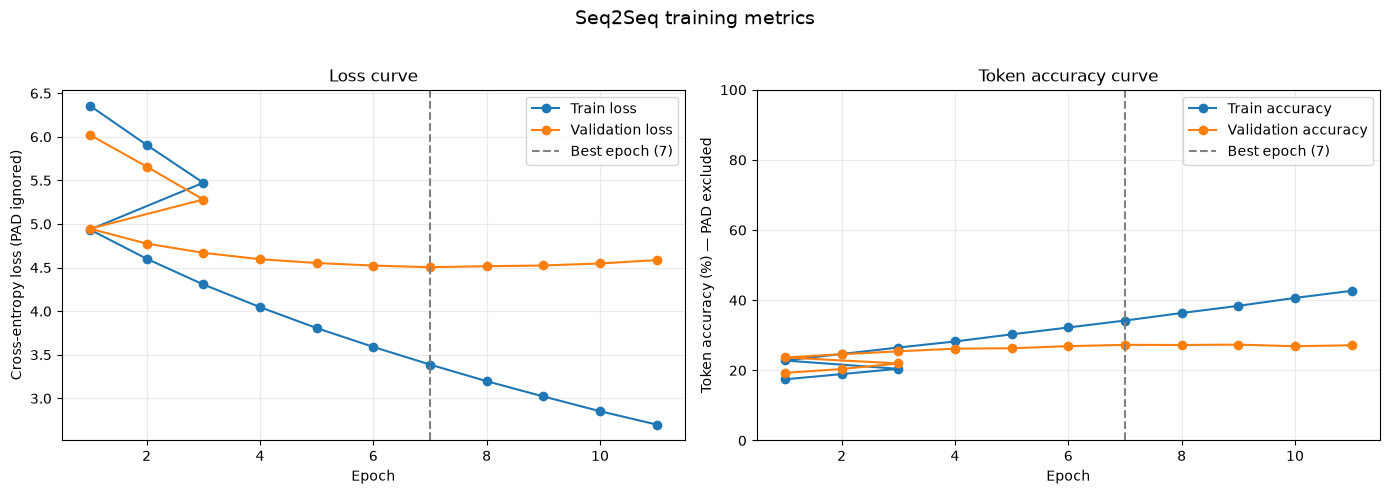

,지표,첫 epoch,최적 validation loss epoch,마지막 epoch
0,Train loss,6.356835,3.387900,2.699635
1,Validation loss,6.021836,4.504827,4.586034
2,Train token accuracy (%),17.441635,34.204466,42.683863
3,Validation token accuracy (%),19.272833,27.270381,27.151015


해석 가이드: loss는 낮을수록, PAD 제외 token accuracy는 높을수록 좋습니다. 
마지막 epoch의 train-validation accuracy 차이는 15.53%p입니다. 
validation loss가 상승하거나 accuracy 격차가 커지면 과적합 가능성을 확인하세요. 
token accuracy는 단어 위치별 일치도이므로 Step 4~5의 실제 요약 품질 비교도 함께 판단해야 합니다.


In [18]:
# Step 3-4. loss와 PAD 제외 token accuracy를 함께 시각화해 학습·일반화 추세를 확인합니다.
history_df = pd.DataFrame(history)
display(history_df)

best_row = history_df.loc[history_df["val_loss"].idxmin()]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# 왼쪽: cross-entropy loss. 낮을수록 좋습니다.
axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
axes[0].axvline(best_epoch, color="gray", linestyle="--", label=f"Best epoch ({best_epoch})")
axes[0].set(xlabel="Epoch", ylabel="Cross-entropy loss (PAD ignored)", title="Loss curve")
axes[0].legend()
axes[0].grid(alpha=0.25)

# 오른쪽: PAD 토큰을 제외한 token-level accuracy. 높을수록 좋습니다.
axes[1].plot(history_df["epoch"], history_df["train_accuracy"], marker="o", label="Train accuracy")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Validation accuracy")
axes[1].axvline(best_epoch, color="gray", linestyle="--", label=f"Best epoch ({best_epoch})")
axes[1].set(xlabel="Epoch", ylabel="Token accuracy (%) — PAD excluded", title="Token accuracy curve", ylim=(0, 100))
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.suptitle("Seq2Seq training metrics", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / f"{CONFIG['EXPERIMENT_NAME']}_training_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

trend_report = pd.DataFrame({
    "지표": ["Train loss", "Validation loss", "Train token accuracy (%)", "Validation token accuracy (%)"],
    "첫 epoch": [
        history_df["train_loss"].iloc[0], history_df["val_loss"].iloc[0],
        history_df["train_accuracy"].iloc[0], history_df["val_accuracy"].iloc[0],
    ],
    "최적 validation loss epoch": [
        best_row["train_loss"], best_row["val_loss"],
        best_row["train_accuracy"], best_row["val_accuracy"],
    ],
    "마지막 epoch": [
        history_df["train_loss"].iloc[-1], history_df["val_loss"].iloc[-1],
        history_df["train_accuracy"].iloc[-1], history_df["val_accuracy"].iloc[-1],
    ],
})
display(trend_report)

accuracy_gap = history_df["train_accuracy"].iloc[-1] - history_df["val_accuracy"].iloc[-1]
print(
    f"해석 가이드: loss는 낮을수록, PAD 제외 token accuracy는 높을수록 좋습니다. \n"
    f"마지막 epoch의 train-validation accuracy 차이는 {accuracy_gap:.2f}%p입니다. \n"
    "validation loss가 상승하거나 accuracy 격차가 커지면 과적합 가능성을 확인하세요. \n"
    "token accuracy는 단어 위치별 일치도이므로 Step 4~5의 실제 요약 품질 비교도 함께 판단해야 합니다."
)

### Step 4. 실제 결과와 요약문 비교하기 (추상적 요약)

```
# 원래의 요약문(headlines 열)과 학습을 통해 얻은 추상적 요약의 결과를 비교해 보세요.
```

```
1. 각 검증 표본에서 실제 headline의 내용어(불용어·특수 토큰 제외) 중 예측 headline에 포함된 비율을 계산
2. 핵심어 포함을 자동으로 점검하는 보조 지표이며, 최종 품질 판단 시에는 원문·참조·예측을 함께 읽음
```

In [19]:
# Step 4-1. 정수 시퀀스 복원, greedy decoding, 참조 핵심어 포함률 함수를 정의합니다.
def decode_ids(ids: list[int], id_to_token: dict) -> str:
    tokens = []
    for token_id in ids:
        token = id_to_token.get(int(token_id), UNK_TOKEN)
        if token in {PAD_TOKEN, SOS_TOKEN}:
            continue
        if token == EOS_TOKEN:
            break
        tokens.append(token)
    return " ".join(tokens)


def predict_summary(source_clean: str) -> str:
    source_ids = torch.tensor(
        [encode_text(source_clean, src_vocab, CONFIG["MAX_SOURCE_LEN"])], dtype=torch.long, device=DEVICE
    )
    predicted_ids = model.greedy_decode(source_ids, CONFIG["DECODE_MAX_LEN"])
    return decode_ids(predicted_ids, tgt_id_to_token)


def content_keywords(summary: str) -> list[str]:
    # headline 핵심어의 근사치: 불용어·특수 토큰·한 글자 토큰을 제외하고 최초 등장 순서를 유지합니다.
    keywords = []
    seen = set()
    for token in preprocess_sentence(summary, remove_stopwords=False).split():
        if token not in STOP_WORDS and token not in {SOS_TOKEN, EOS_TOKEN} and len(token) > 1 and token not in seen:
            keywords.append(token)
            seen.add(token)
    return keywords


def keyword_recall(reference: str, candidate: str) -> tuple[float, list[str]]:
    reference_keywords = content_keywords(reference)
    candidate_tokens = set(preprocess_sentence(candidate, remove_stopwords=False).split())
    matched = [word for word in reference_keywords if word in candidate_tokens]
    score = len(matched) / len(reference_keywords) if reference_keywords else np.nan
    return score, matched

In [20]:
# Step 4-2. 테스트 표본의 원문, 실제 요약, 예측 요약, 핵심어 포함률을 표로 확인합니다.
eval_count = min(CONFIG["N_EVAL_SAMPLES"], len(test_df))
eval_rows = test_df.sample(eval_count, random_state=CONFIG["SEED"]).reset_index(drop=True)
evaluation_rows = []
for _, row in eval_rows.iterrows():
    predicted = predict_summary(row["source_clean"])
    recall, matched = keyword_recall(row["target_clean"], predicted)
    evaluation_rows.append({
        "원문(앞 220자)": row["source_raw"][:220].replace("\n", " "),
        "실제 요약": row["target_clean"],
        "Abstractive 예측": predicted,
        "실제 핵심어": ", ".join(content_keywords(row["target_clean"])),
        "일치 핵심어": ", ".join(matched),
        "핵심어 포함률": recall,
    })

abstractive_eval = pd.DataFrame(evaluation_rows)
mean_abstractive_keyword_recall = abstractive_eval["핵심어 포함률"].mean()
display(abstractive_eval)
print(f"Abstractive 평균 핵심어 포함률: {mean_abstractive_keyword_recall:.3f}")
abstractive_eval.to_csv(ARTIFACT_DIR / f"{CONFIG['EXPERIMENT_NAME']}_abstractive_examples.csv", index=False, encoding="utf-8-sig")

,원문(앞 220자),실제 요약,Abstractive 예측,실제 핵심어,일치 핵심어,핵심어 포함률
0,The police have detained a man for keeping the decomposed body of his mother at home in Kolkata for allegedly about 17-18 days. The matter came to light whe...,kolkata man spends days with mother decomposing body,man <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>,"kolkata, man, spends, days, mother, decomposing, body",man,0.142857
1,Indian spinner Ravichandran Ashwin was seen undergoing a solo indoor bowling session while the rest of the Indian team preferred to take a day off ahead of ...,ashwin undergoes solo practice session ahead of sydney test,<unk> <unk> <unk> <unk> <unk> <unk> in india,"ashwin, undergoes, solo, practice, session, ahead, sydney, test",,0.000000
2,India's aviation regulator DGCA has reportedly advised airlines to operate relief flights to flood-hit Kerala and not to overprice air tickets. It also info...,airlines advised not to overprice tickets to kerala reports,india to cut <unk> <unk> in <unk> <unk>,"airlines, advised, overprice, tickets, kerala, reports",,0.000000
3,"Sandra Samuel, the nanny who saved the then two-year-old Moshe Holtzberg during the 26/11 Mumbai attacks, has revealed Moshe is still afraid of darkness. ""H...",moshe still afraid of darkness nanny who saved him during,<unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>,"moshe, still, afraid, darkness, nanny, saved",,0.000000
4,"Flipkart's minority shareholder Tencent has the first right to purchase any shares if any existing shareholder plans to sell it to Alibaba, Walmart has said...",alibaba needs tencent approval to buy stake in flipkart,<unk> <unk> may be <unk> in india <unk> <unk>,"alibaba, needs, tencent, approval, buy, stake, flipkart",,0.000000
5,"One more body was recovered from south Kolkata where a part of the Majerhat bridge collapsed on Tuesday, taking the death toll to two. The body is suspected...",second body recovered from kolkata bridge collapse site,<unk> die after death in <unk> train accident,"second, body, recovered, kolkata, bridge, collapse, site",,0.000000
6,"After it was revealed that actor Diljit Dosanjh will get his own wax statue at Madame Tussauds in Delhi, he said, ""Finally yeh din bhi aa gaya @madametussau...",yeh din bhi aa gaya diljit on wax statue at madame tussauds,<unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>,"yeh, din, bhi, aa, gaya, diljit, wax, statue, madame, tussauds",,0.000000
7,"Condoling the demise of former Team India captain and manager Ajit Wadekar, former captain and coach Anil Kumble tweeted that Wadekar was ""a shrewd tacticia...",wadekar was father figure shrewd tactician anil kumble,ex aus captain <unk> <unk> <unk> <unk> <unk>,"wadekar, father, figure, shrewd, tactician, anil, kumble",,0.000000


Abstractive 평균 핵심어 포함률: 0.018


In [21]:
# Step 4-3. Ablation 결과를 파일에 누적합니다. 서로 다른 preset을 실행한 뒤 이 파일을 비교에 사용하세요.
def append_ablation_record() -> pd.DataFrame:
    result_path = ARTIFACT_DIR / "ablation_results.csv"
    record = {
        "experiment": CONFIG["EXPERIMENT_NAME"],
        "active_ablation": CONFIG["ACTIVE_ABLATION"],
        "use_attention": CONFIG["USE_ATTENTION"],
        "remove_source_stopwords": CONFIG["REMOVE_SOURCE_STOPWORDS"],
        "max_source_len": CONFIG["MAX_SOURCE_LEN"],
        "src_vocab_size": CONFIG["SRC_VOCAB_SIZE"],
        "tgt_vocab_size": CONFIG["TGT_VOCAB_SIZE"],
        "embedding_dim": CONFIG["EMBED_DIM"],
        "hidden_dim": CONFIG["HIDDEN_DIM"],
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_token_accuracy": best_row["val_accuracy"],
        "last_train_token_accuracy": history_df["train_accuracy"].iloc[-1],
        "last_val_token_accuracy": history_df["val_accuracy"].iloc[-1],
        "mean_keyword_recall": mean_abstractive_keyword_recall,
        "timestamp": pd.Timestamp.now().isoformat(timespec="seconds"),
    }
    previous = pd.read_csv(result_path) if result_path.exists() else pd.DataFrame()
    results = pd.concat([previous, pd.DataFrame([record])], ignore_index=True)
    results.to_csv(result_path, index=False, encoding="utf-8-sig")
    return results

ablation_results = append_ablation_record()
display(ablation_results.tail(10))
print("다른 preset을 실행하면 아래 파일에 실험 결과가 누적됩니다:", ARTIFACT_DIR / "ablation_results.csv")

,experiment,active_ablation,use_attention,remove_source_stopwords,max_source_len,src_vocab_size,tgt_vocab_size,embedding_dim,hidden_dim,best_epoch,best_val_loss,mean_keyword_recall,timestamp,best_val_token_accuracy,last_train_token_accuracy,last_val_token_accuracy
0,ex08_baseline,baseline,True,True,60,15000,5000,128,256,10,4.510025,0.053571,2026-08-13T17:29:19,NaN,NaN,NaN
1,ex08_baseline,baseline,True,True,60,15000,5000,128,256,7,4.504827,0.017857,2026-08-13T18:40:23,27.270381,42.683863,27.151015


다른 preset을 실행하면 아래 파일에 실험 결과가 누적됩니다: C:\Users\eaglesjo\work\news_summarization\artifacts\ablation_results.csv


### Step 5. Summa을 이용해서 추출적 요약해보기

```
1. 추출 요약은 원문 문장을 선택하므로 문장 형태를 유지할 가능성이 있지만, headline처럼 짧은 재서술을 직접 생성하지는 않음
2. 동일 표본에 대해 핵심어 포함률, 길이·반복 기반의 자동 문법 점검 신호, 그리고 사람이 직접 채우는 문법 완성도 점수(1~5)를 한 표에서 비교
```
> 자동 문법 신호는 문법을 판정하지 않음

> 수동 문법 점수는 원문·참조·후보를 읽고 채우며, 이 값이 있어야 문법 완성도에 대한 결론을 제시할 수 있음

In [22]:
# Step 5-1. Summa 추출 요약과 짧은 입력용 안전한 fallback을 정의합니다.
def first_sentence_fallback(text: str) -> str:
    sentences = [sentence.strip() for sentence in re.split(r"(?<=[.!?])\s+", str(text)) if sentence.strip()]
    return sentences[0] if sentences else str(text).strip()


def extractive_summary(source_raw: str) -> str:
    source = re.sub(r"<[^>]+>", " ", str(source_raw)).strip()
    try:
        summary = textrank_summarize(source, ratio=CONFIG["SUMMA_RATIO"], split=False)
        return summary.strip() if summary.strip() else first_sentence_fallback(source)
    except (ValueError, IndexError):
        # Summa는 문장 수가 너무 적거나 graph를 만들 수 없을 때 ValueError를 낼 수 있습니다.
        return first_sentence_fallback(source)


def grammar_signals(text: str) -> dict:
    tokens = preprocess_sentence(text, remove_stopwords=False).split()
    duplicate_ratio = 1 - (len(set(tokens)) / len(tokens)) if tokens else np.nan
    return {
        "후보 길이(토큰)": len(tokens),
        "반복 토큰 비율": duplicate_ratio,
        "종결부호 존재": bool(re.search(r"[.!?][\"']?\s*$", str(text).strip())),
    }

In [ ]:
# Step 5-2. 동일 표본에서 Abstractive·Extractive 결과를 비교합니다.
comparison_rows = []
for _, row in eval_rows.iterrows():
    abstractive = predict_summary(row["source_clean"])
    extractive = extractive_summary(row["source_raw"])
    for method, candidate in [("Abstractive (Seq2Seq)", abstractive), ("Extractive (Summa)", extractive)]:
        recall, matched = keyword_recall(row["target_clean"], candidate)
        signals = grammar_signals(candidate)
        comparison_rows.append({
            "방법": method,
            "원문(앞 160자)": row["source_raw"][:160].replace("\n", " "),
            "실제 요약": row["target_clean"],
            "후보 요약": candidate,
            "실제 핵심어": ", ".join(content_keywords(row["target_clean"])),
            "일치 핵심어": ", ".join(matched),
            "핵심어 포함률": recall,
            **signals,
            "수동 문법 점수(1~5)": np.nan,
            "문법성 검토 메모": "원문·참조와 비교 후 작성",
        })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)
comparison_df.to_csv(ARTIFACT_DIR / f"{CONFIG['EXPERIMENT_NAME']}_method_comparison.csv", index=False, encoding="utf-8-sig")

,방법,원문(앞 160자),실제 요약,후보 요약,실제 핵심어,일치 핵심어,핵심어 포함률,후보 길이(토큰),반복 토큰 비율,종결부호 존재,수동 문법 점수(1~5),문법성 검토 메모
0,Abstractive (Seq2Seq),The police have detained a man for keeping the decomposed body of his mother at home in Kolkata for allegedly about 17-18 days. The matter came to light whe...,kolkata man spends days with mother decomposing body,man <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>,"kolkata, man, spends, days, mother, decomposing, body",man,0.142857,1,0.000000,False,NaN,원문·참조와 비교 후 작성
1,Extractive (Summa),The police have detained a man for keeping the decomposed body of his mother at home in Kolkata for allegedly about 17-18 days. The matter came to light whe...,kolkata man spends days with mother decomposing body,The police have detained a man for keeping the decomposed body of his mother at home in Kolkata for allegedly about 17-18 days.,"kolkata, man, spends, days, mother, decomposing, body","kolkata, man, days, mother, body",0.714286,21,0.095238,True,NaN,원문·참조와 비교 후 작성
2,Abstractive (Seq2Seq),Indian spinner Ravichandran Ashwin was seen undergoing a solo indoor bowling session while the rest of the Indian team preferred to take a day off ahead of ...,ashwin undergoes solo practice session ahead of sydney test,<unk> <unk> <unk> <unk> <unk> <unk> in india,"ashwin, undergoes, solo, practice, session, ahead, sydney, test",,0.000000,2,0.000000,False,NaN,원문·참조와 비교 후 작성
3,Extractive (Summa),Indian spinner Ravichandran Ashwin was seen undergoing a solo indoor bowling session while the rest of the Indian team preferred to take a day off ahead of ...,ashwin undergoes solo practice session ahead of sydney test,Indian spinner Ravichandran Ashwin was seen undergoing a solo indoor bowling session while the rest of the Indian team preferred to take a day off ahead of ...,"ashwin, undergoes, solo, practice, session, ahead, sydney, test","ashwin, solo, session, ahead, sydney, test",0.750000,28,0.142857,True,NaN,원문·참조와 비교 후 작성
4,Abstractive (Seq2Seq),India's aviation regulator DGCA has reportedly advised airlines to operate relief flights to flood-hit Kerala and not to overprice air tickets. It also info...,airlines advised not to overprice tickets to kerala reports,india to cut <unk> <unk> in <unk> <unk>,"airlines, advised, overprice, tickets, kerala, reports",,0.000000,4,0.000000,False,NaN,원문·참조와 비교 후 작성
5,Extractive (Summa),India's aviation regulator DGCA has reportedly advised airlines to operate relief flights to flood-hit Kerala and not to overprice air tickets. It also info...,airlines advised not to overprice tickets to kerala reports,India's aviation regulator DGCA has reportedly advised airlines to operate relief flights to flood-hit Kerala and not to overprice air tickets.,"airlines, advised, overprice, tickets, kerala, reports","airlines, advised, overprice, tickets, kerala",0.833333,22,0.090909,True,NaN,원문·참조와 비교 후 작성
6,Abstractive (Seq2Seq),"Sandra Samuel, the nanny who saved the then two-year-old Moshe Holtzberg during the 26/11 Mumbai attacks, has revealed Moshe is still afraid of darkness. ""H...",moshe still afraid of darkness nanny who saved him during,<unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>,"moshe, still, afraid, darkness, nanny, saved",,0.000000,0,NaN,False,NaN,원문·참조와 비교 후 작성
7,Extractive (Summa),"Sandra Samuel, the nanny who saved the then two-year-old Moshe Holtzberg during the 26/11 Mumbai attacks, has revealed Moshe is still afraid of darkness. ""H...",moshe still afraid of darkness nanny who saved him during,But in the night he wants all lights on.,"moshe, still, afraid, darkness, nanny, saved",,0.000000,9,0.000000,True,NaN,원문·참조와 비교 후 작성
8,Abstractive (Seq2Seq),"Flipkart's minority shareholder Tencent has the first right to purchase any shares if any existing shareholder plans to sell it to Alibaba, Walmart has said...",alibaba needs tencent approval to buy stake in flipkart,<unk> <unk> may be <unk> in india <unk> <unk>,"alibaba, needs, tencent, approval, buy, stake, flipkart",,0.00000

In [26]:
# Step 5-3. 비교 분석표를 만듭니다. 수동 문법 점수 열을 채운 후 이 셀을 다시 실행하세요.
method_summary = comparison_df.groupby("방법", as_index=False).agg(
    표본수=("방법", "size"),
    평균_핵심어_포함률=("핵심어 포함률", "mean"),
    평균_후보_길이=("후보 길이(토큰)", "mean"),
    평균_반복_토큰_비율=("반복 토큰 비율", "mean"),
    종결부호_비율=("종결부호 존재", "mean"),
    평균_수동_문법_점수=("수동 문법 점수(1~5)", "mean"),
)
display(method_summary)

if comparison_df["수동 문법 점수(1~5)"].notna().any():
    grammar_note = "수동 문법 점수의 평균도 위 표에서 비교할 수 있습니다."
else:
    grammar_note = "문법 완성도 결론을 위해 comparison_df의 '수동 문법 점수(1~5)'와 메모를 작성한 뒤 이 셀을 다시 실행하세요."
print(grammar_note)

best_keyword_method = method_summary.loc[method_summary["평균_핵심어_포함률"].idxmax(), "방법"]
print(
    f"핵심어 포함률 기준 우세 방법: {best_keyword_method}. \n"
    "반복 토큰 비율과 종결부호 비율은 문법성의 보조 신호일 뿐이며, 최종 문법 판단은 수동 점수와 메모를 근거로 작성합니다."
)

,방법,표본수,평균_핵심어_포함률,평균_후보_길이,평균_반복_토큰_비율,종결부호_비율,평균_수동_문법_점수
0,Abstractive (Seq2Seq),8,0.017857,2.5,0.000000,0.0,NaN
1,Extractive (Summa),8,0.662202,23.5,0.099786,1.0,NaN


문법 완성도 결론을 위해 comparison_df의 '수동 문법 점수(1~5)'와 메모를 작성한 뒤 이 셀을 다시 실행하세요.
핵심어 포함률 기준 우세 방법: Extractive (Summa). 
반복 토큰 비율과 종결부호 비율은 문법성의 보조 신호일 뿐이며, 최종 문법 판단은 수동 점수와 메모를 근거로 작성합니다.
